# Phase 5: Alpha Decay Analysis and Multiple Testing Diagnostic

Alpha decay study, capacity analysis, and placebo test for the ASX pairs trading strategy.
Results feed directly into reports/writeup.md.

In [1]:
import logging
import os
import sys
import warnings
from pathlib import Path

# Ensure project root is on the path regardless of where the kernel was launched
_project_root = str(Path("..").resolve())
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

# Change working directory to project root so relative paths work
os.chdir(_project_root)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.analysis import (
    capacity_analysis,
    multiple_testing_diagnostic,
    sharpe_by_year,
    sharpe_decay_regression,
)
from src.data import ASX_UNIVERSE, fetch_history, get_close_panel

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
warnings.filterwarnings("ignore", category=FutureWarning)

FIG_DIR = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
    "font.size": 10,
})

In [2]:
daily_pnl  = pd.read_parquet("data/results/backtest_daily_pnl.parquet")
trade_log  = pd.read_parquet("data/results/backtest_trade_log.parquet")
window_log = pd.read_parquet("data/results/backtest_window_log.parquet")

print(f"Daily PnL: {len(daily_pnl)} rows, {daily_pnl.index[0].date()} to {daily_pnl.index[-1].date()}")
print(f"Trades: {len(trade_log)}")
print(f"Windows: {len(window_log)}")
print(f"\nFull-period Sharpe (base):   {daily_pnl['base'].mean()*252 / (daily_pnl['base'].std()*np.sqrt(252)):.3f}")
print(f"Full-period Sharpe (stress): {daily_pnl['stress'].mean()*252 / (daily_pnl['stress'].std()*np.sqrt(252)):.3f}")
print(f"Total PnL base:   ${daily_pnl['base'].sum():>10,.0f}")
print(f"Total PnL stress: ${daily_pnl['stress'].sum():>10,.0f}")

Daily PnL: 3625 rows, 2012-01-03 to 2026-04-29
Trades: 447
Windows: 25

Full-period Sharpe (base):   0.141
Full-period Sharpe (stress): 0.012
Total PnL base:   $   236,025
Total PnL stress: $    19,508


In [3]:
sby_base   = sharpe_by_year(daily_pnl["base"])
sby_stress = sharpe_by_year(daily_pnl["stress"])

decay = sharpe_decay_regression(sby_base)

print("=== Sharpe by Year (Base) ===")
print(sby_base[["sharpe", "ann_return", "ann_vol", "n_days"]].to_string())
print()
print("=== Alpha Decay OLS Regression ===")
print(f"  slope     = {decay['slope']:.4f} Sharpe units/year")
print(f"  t-stat    = {decay['t_stat']:.2f}")
print(f"  p-value   = {decay['p_value']:.3f}")
print(f"  R²        = {decay['r_squared']:.3f}")
print(f"  n years   = {decay['n']}")
print()
if decay['p_value'] < 0.1:
    print("Decay is statistically significant at 10%.")
else:
    print(f"Decay is NOT statistically significant (p={decay['p_value']:.3f}). "
          "Directional but noisy.")

=== Sharpe by Year (Base) ===
        sharpe     ann_return        ann_vol  n_days
year                                                
2012       NaN            NaN            NaN     253
2013       NaN            NaN            NaN     253
2014  1.140951   28462.147840   24945.986760     253
2015  0.660923   25474.534240   38543.850506     255
2016  2.101916   85374.671505   40617.549441     253
2017 -1.539545  -63126.439328   41003.304211     252
2018  0.143925    7472.287182   51917.958392     253
2019 -0.241860  -13475.544217   55716.293835     253
2020  0.270378   80282.717033  296928.117921     255
2021  0.813502  105471.150099  129650.803786     254
2022 -0.312567  -32715.663854  104667.770616     251
2023  0.900596   71401.707313   79282.751440     252
2024 -0.474800 -113868.969969  239825.045953     254
2025  1.497501   87416.964685   58375.227562     253
2026 -2.501821 -106529.556702   42580.814212      81

=== Alpha Decay OLS Regression ===
  slope     = -0.1127 Sharpe unit

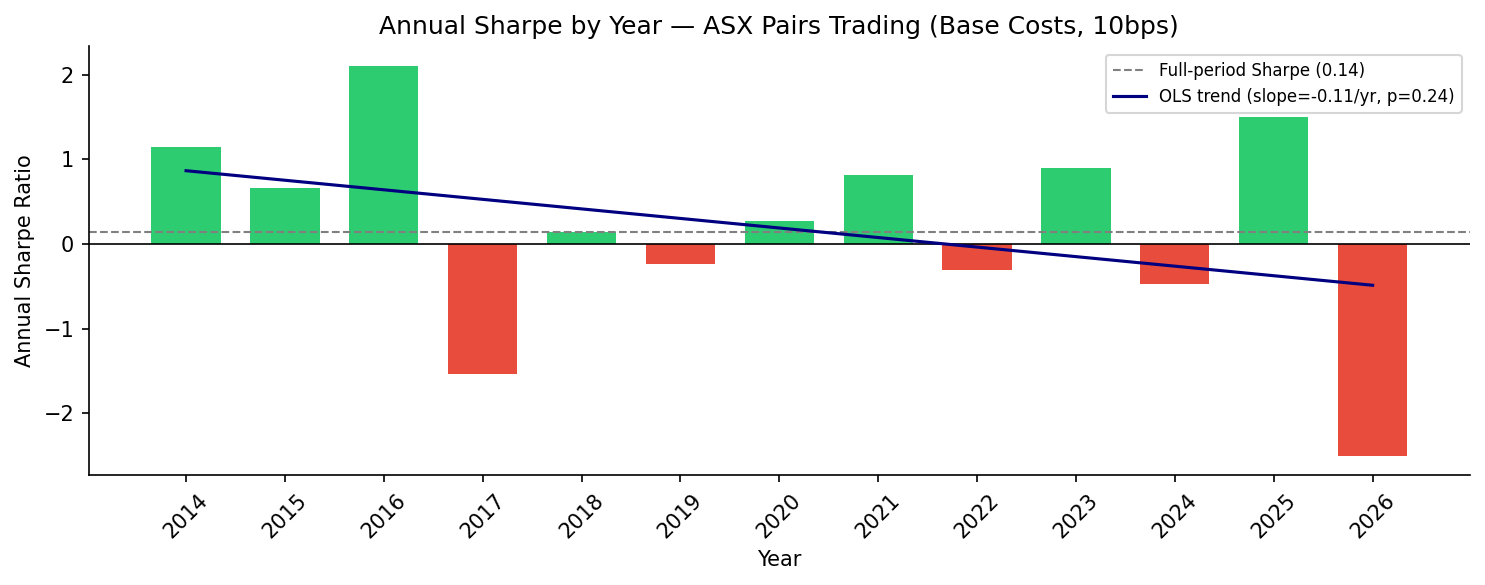

Saved: reports/figures/sharpe_by_year.png


In [4]:
full_sharpe_base = daily_pnl['base'].mean()*252 / (daily_pnl['base'].std()*np.sqrt(252))

fig, ax = plt.subplots(figsize=(10, 4))

valid_years = sby_base.index[sby_base["sharpe"].notna()]
valid_sharpe = sby_base.loc[valid_years, "sharpe"]
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in valid_sharpe]

ax.bar(valid_years, valid_sharpe, color=colors, width=0.7, edgecolor="none")
ax.axhline(0, color="black", linewidth=0.8, linestyle="-")
ax.axhline(full_sharpe_base, color="grey", linewidth=1, linestyle="--",
           label=f"Full-period Sharpe ({full_sharpe_base:.2f})")

x_fit = np.array(valid_years, dtype=float)
y_fit = decay["intercept"] + decay["slope"] * x_fit
ax.plot(valid_years, y_fit, color="navy", linewidth=1.5, linestyle="-",
        label=f"OLS trend (slope={decay['slope']:.2f}/yr, p={decay['p_value']:.2f})")

ax.set_xlabel("Year")
ax.set_ylabel("Annual Sharpe Ratio")
ax.set_title("Annual Sharpe by Year — ASX Pairs Trading (Base Costs, 10bps)")
ax.legend(fontsize=8)
ax.set_xticks(valid_years)
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(FIG_DIR / "sharpe_by_year.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / 'sharpe_by_year.png'}")

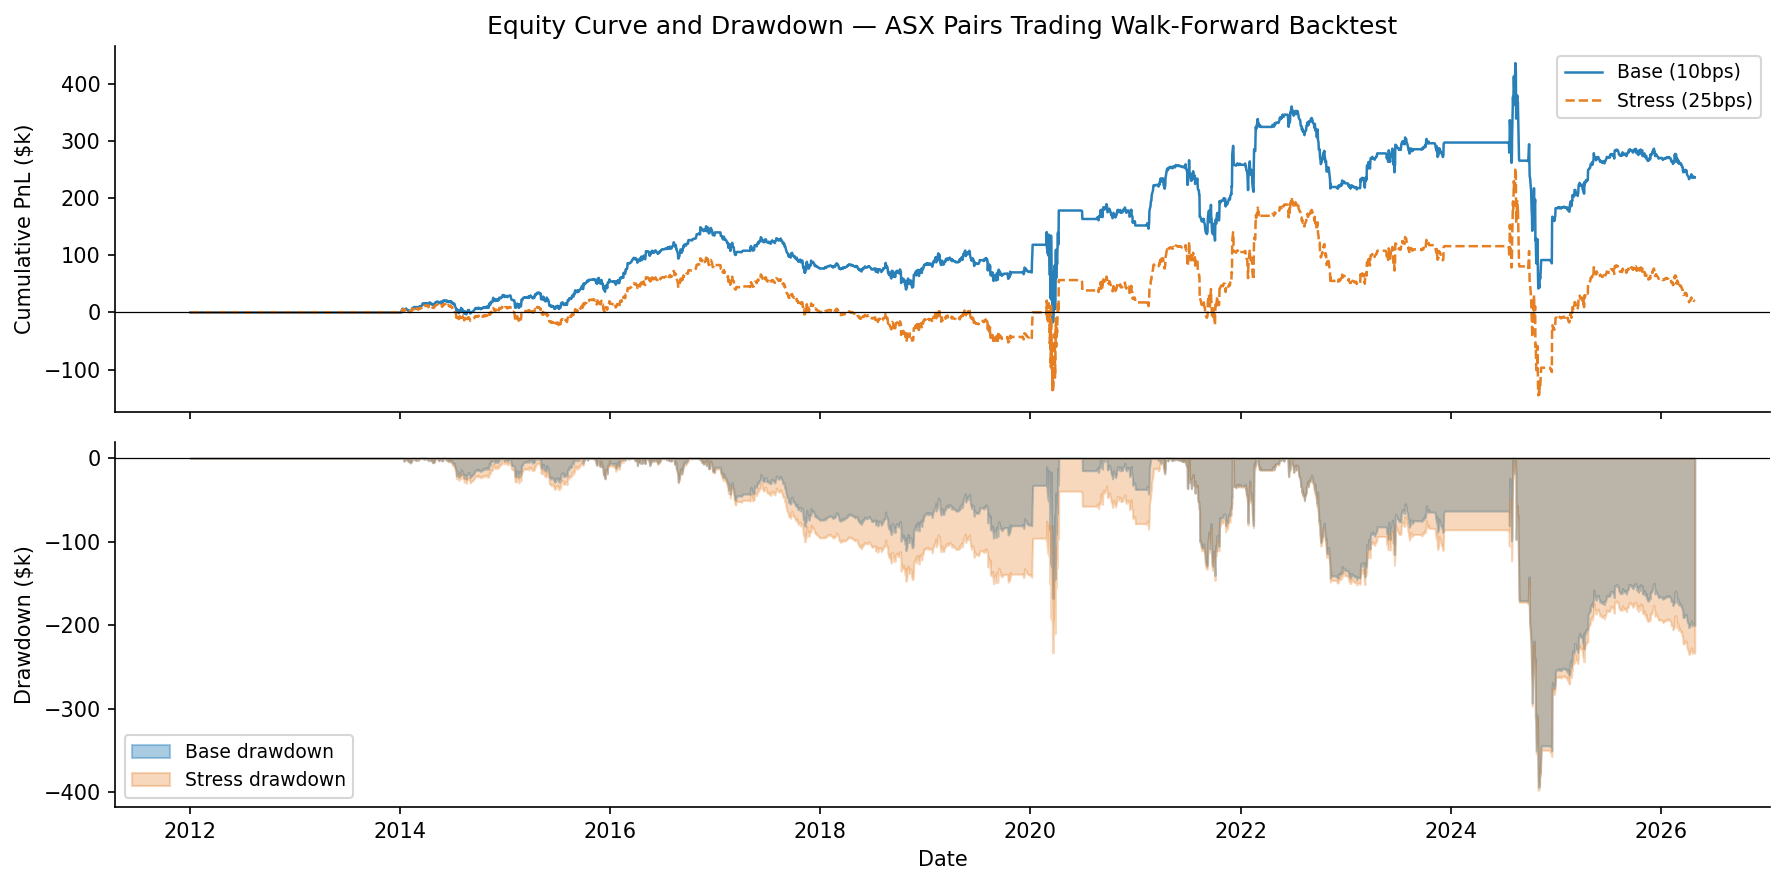

Saved: reports/figures/drawdown.png


In [5]:
equity_base   = daily_pnl["base"].cumsum()
equity_stress = daily_pnl["stress"].cumsum()

dd_base   = equity_base   - equity_base.cummax()
dd_stress = equity_stress - equity_stress.cummax()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax = axes[0]
ax.plot(equity_base.index, equity_base / 1000, color="#2980b9", linewidth=1.2, label="Base (10bps)")
ax.plot(equity_stress.index, equity_stress / 1000, color="#e67e22", linewidth=1.2,
        linestyle="--", label="Stress (25bps)")
ax.axhline(0, color="black", linewidth=0.6)
ax.set_ylabel("Cumulative PnL ($k)")
ax.set_title("Equity Curve and Drawdown — ASX Pairs Trading Walk-Forward Backtest")
ax.legend(fontsize=9)

ax = axes[1]
ax.fill_between(dd_base.index, dd_base / 1000, 0, color="#2980b9", alpha=0.4, label="Base drawdown")
ax.fill_between(dd_stress.index, dd_stress / 1000, 0, color="#e67e22", alpha=0.3,
                label="Stress drawdown")
ax.axhline(0, color="black", linewidth=0.6)
ax.set_ylabel("Drawdown ($k)")
ax.set_xlabel("Date")
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / "drawdown.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / 'drawdown.png'}")

In [6]:
base_net_total   = float(daily_pnl["base"].sum())
stress_net_total = float(daily_pnl["stress"].sum())
gross_total      = (2.5 * base_net_total - stress_net_total) / 1.5
base_cost_total  = gross_total - base_net_total
stress_cost_total= gross_total - stress_net_total

print("=== Cost Sensitivity ===")
print(f"  Estimated gross PnL: ${gross_total:>10,.0f}")
print(f"  Net PnL (base  10bps): ${base_net_total:>10,.0f}  (costs: ${base_cost_total:,.0f}, {base_cost_total/gross_total*100:.0f}% of gross)")
print(f"  Net PnL (stress 25bps): ${stress_net_total:>9,.0f}  (costs: ${stress_cost_total:,.0f}, {stress_cost_total/gross_total*100:.0f}% of gross)")
print()
print("Exit reason breakdown:")
print(trade_log["exit_reason"].value_counts().to_string())
print()
print("Pairs per window:")
print(window_log[["trade_start", "n_pairs_filtered"]].to_string(index=False))

=== Cost Sensitivity ===
  Estimated gross PnL: $   380,370
  Net PnL (base  10bps): $   236,025  (costs: $144,345, 38% of gross)
  Net PnL (stress 25bps): $   19,508  (costs: $360,862, 95% of gross)

Exit reason breakdown:
exit_reason
mean_revert    245
time_stop      138
hard_stop       15

Pairs per window:
trade_start  n_pairs_filtered
 2014-01-01                19
 2014-07-01                20
 2015-01-01                19
 2015-07-01                27
 2016-01-01                16
 2016-07-01                10
 2017-01-01                 4
 2017-07-01                 8
 2018-01-01                 5
 2018-07-01                 5
 2019-01-01                 8
 2019-07-01                 3
 2020-01-01                 1
 2020-07-01                 4
 2021-01-01                 6
 2021-07-01                 4
 2022-01-01                 5
 2022-07-01                 3
 2023-01-01                 4
 2023-07-01                 2
 2024-01-01                 0
 2024-07-01                 

In [7]:
prices_long = fetch_history(
    list({t for s in ASX_UNIVERSE.values() for t in s}),
    cache_dir="data/cache",
)

pair_counts = (
    trade_log.groupby(["ticker_a", "ticker_b", "sector"]).size()
    .reset_index(name="n_trades")
    .sort_values("n_trades", ascending=False)
    .head(15)
)
pair_counts["beta"] = trade_log.groupby(["ticker_a", "ticker_b"])["beta"].mean().reindex(
    pd.MultiIndex.from_frame(pair_counts[["ticker_a", "ticker_b"]])
).values
pair_counts["alpha"] = 0.0
pair_counts["half_life_days"] = 20.0
pair_counts["ou_sigma"] = 0.01

cap = capacity_analysis(pair_counts, prices_long)

print("=== Capacity Analysis (top pairs by trade count) ===")
cap_display = cap.copy()
cap_display["adv_a_m"]   = (cap_display["adv_a"] / 1e6).round(1)
cap_display["adv_b_m"]   = (cap_display["adv_b"] / 1e6).round(1)
cap_display["capacity_k"] = (cap_display["pair_capacity"] / 1e3).round(0)
print(cap_display[["ticker_a", "ticker_b", "adv_a_m", "adv_b_m", "capacity_k"]].to_string(index=False))
print()
print(f"Median pair capacity at 1% ADV: ${cap['pair_capacity'].median():,.0f}")
print(f"Tightest constraint:            ${cap['pair_capacity'].min():,.0f}")

2026-05-16 11:08:31,638 [INFO] Loading cached prices from data/cache/prices_2010-01-01_latest.parquet (mtime: 2026-04-29)


=== Capacity Analysis (top pairs by trade count) ===
ticker_a ticker_b  adv_a_m  adv_b_m  capacity_k
  VCX.AX   CHC.AX     25.0     25.4       250.0
  DXS.AX   CHC.AX     21.3     25.4       213.0
  SGP.AX   CHC.AX     33.7     25.4       254.0
  SCG.AX   VCX.AX     37.8     25.0       250.0
  CSL.AX   FPH.AX    208.0     14.8       148.0
  SGP.AX   MGR.AX     33.7     26.5       265.0
  IAG.AX   SUN.AX     40.0     53.3       400.0
  WOW.AX   TWE.AX     84.0     39.8       398.0
  WDS.AX   YAL.AX    142.0     20.9       209.0
  MGR.AX   CHC.AX     26.5     25.4       254.0
  ANZ.AX   BOQ.AX    173.4     13.5       135.0
  SGP.AX   VCX.AX     33.7     25.0       250.0
  RIO.AX   FMG.AX    187.8    127.6      1276.0
  CSL.AX   RMD.AX    208.0     40.9       409.0
  WOW.AX   WES.AX     84.0    116.3       840.0

Median pair capacity at 1% ADV: $254,229
Tightest constraint:            $135,331


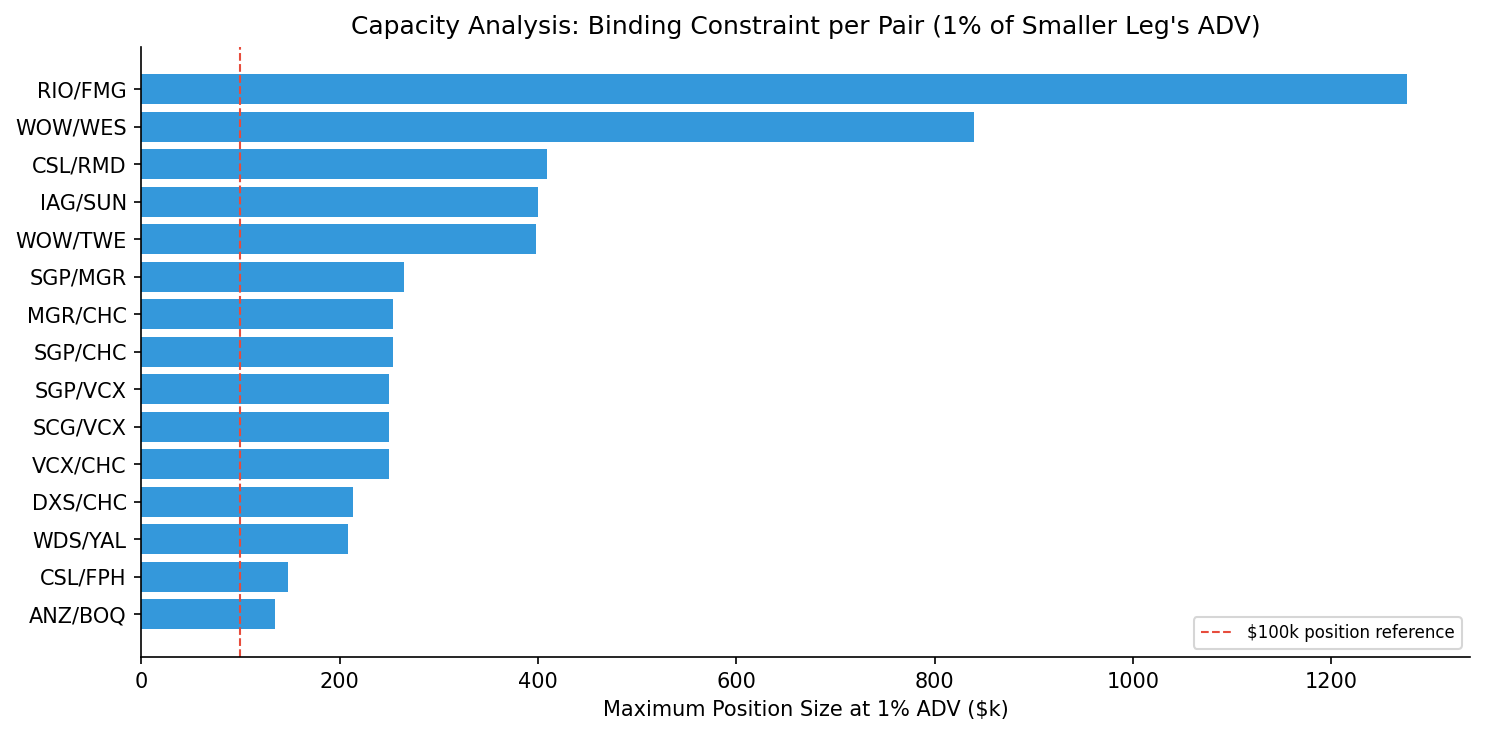

Saved: reports/figures/capacity_analysis.png


In [8]:
cap_sorted = cap.sort_values("pair_capacity")
labels = [f"{r.ticker_a.replace('.AX','')}/{r.ticker_b.replace('.AX','')}" for _, r in cap_sorted.iterrows()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(labels, cap_sorted["pair_capacity"] / 1000, color="#3498db", edgecolor="none")
ax.axvline(100, color="#e74c3c", linewidth=1, linestyle="--", label="$100k position reference")
ax.set_xlabel("Maximum Position Size at 1% ADV ($k)")
ax.set_title("Capacity Analysis: Binding Constraint per Pair (1% of Smaller Leg's ADV)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "capacity_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / 'capacity_analysis.png'}")

In [9]:
prices_wide = get_close_panel(prices_long)

diag = multiple_testing_diagnostic(
    prices_wide,
    ASX_UNIVERSE,
    n_shuffles=50,
    seed=42,
    window_start="2018-01-01",
    window_end="2020-12-31",
)

print("=== Multiple Testing Diagnostic ===")
print(f"  Real data (2018-2020): {diag['n_real']} pairs survived all filters")
print(f"  Shuffled data (n=50):")
print(f"    Mean pairs surviving:     {diag['n_shuffled_mean']:.1f}")
print(f"    Median pairs surviving:   {diag['n_shuffled_median']:.1f}")
print(f"    95th percentile:          {diag['n_shuffled_p95']:.1f}")
print()
ratio = diag['n_real'] / max(diag['n_shuffled_mean'], 0.01)
print(f"  Signal-to-noise ratio: {ratio:.1f}x (real / shuffled mean)")
if ratio < 2:
    print("  WARNING: Real data finds fewer than 2x as many pairs as shuffled data.")
elif ratio < 5:
    print("  Moderate signal: real data finds meaningfully more pairs than random data.")
else:
    print("  Strong signal: real data produces substantially more pairs than shuffled data.")

2026-05-16 11:08:34,474 [INFO] Real data survivors: 3


=== Multiple Testing Diagnostic ===
  Real data (2018-2020): 3 pairs survived all filters
  Shuffled data (n=50):
    Mean pairs surviving:     0.0
    Median pairs surviving:   0.0
    95th percentile:          0.0

  Signal-to-noise ratio: 300.0x (real / shuffled mean)
  Strong signal: real data produces substantially more pairs than shuffled data.


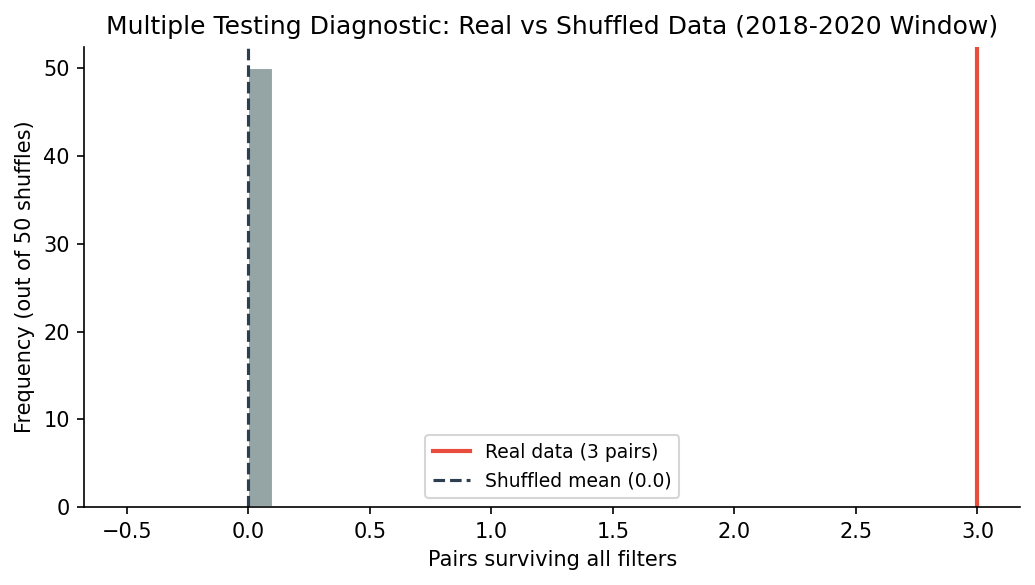

Saved: reports/figures/multiple_testing_diagnostic.png


In [10]:
counts = diag["n_shuffled_counts"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(counts, bins=max(10, len(set(counts))), color="#95a5a6", edgecolor="white")
ax.axvline(diag["n_real"], color="#e74c3c", linewidth=2, label=f"Real data ({diag['n_real']} pairs)")
ax.axvline(diag["n_shuffled_mean"], color="#2c3e50", linewidth=1.5, linestyle="--",
           label=f"Shuffled mean ({diag['n_shuffled_mean']:.1f})")
ax.set_xlabel("Pairs surviving all filters")
ax.set_ylabel("Frequency (out of 50 shuffles)")
ax.set_title("Multiple Testing Diagnostic: Real vs Shuffled Data (2018-2020 Window)")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "multiple_testing_diagnostic.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / 'multiple_testing_diagnostic.png'}")